Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"


Number_clusters     Value_Index 
        27.0000          0.4666

[1] "points" "eig"    "x"      "ac"     "GOF"

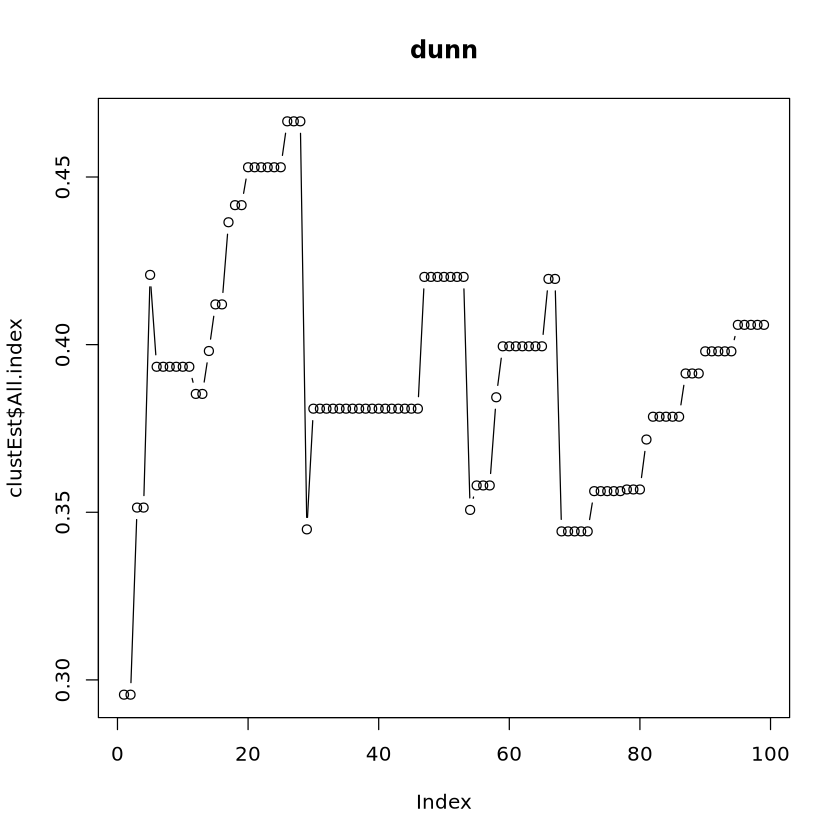

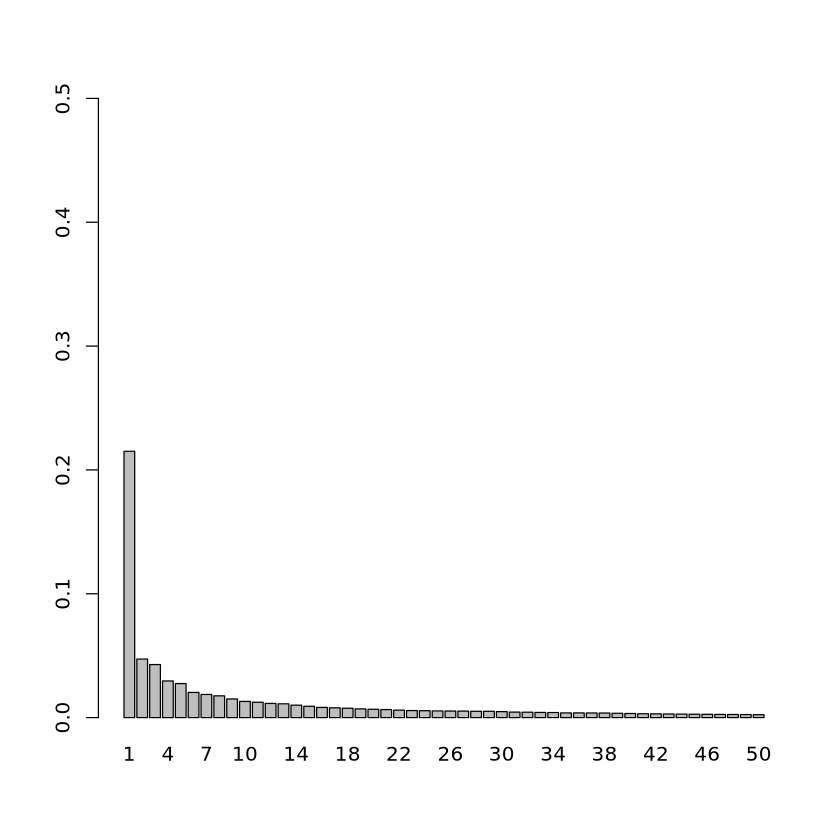

ERROR: Error: object 'cindex_newDataSet_del' not found


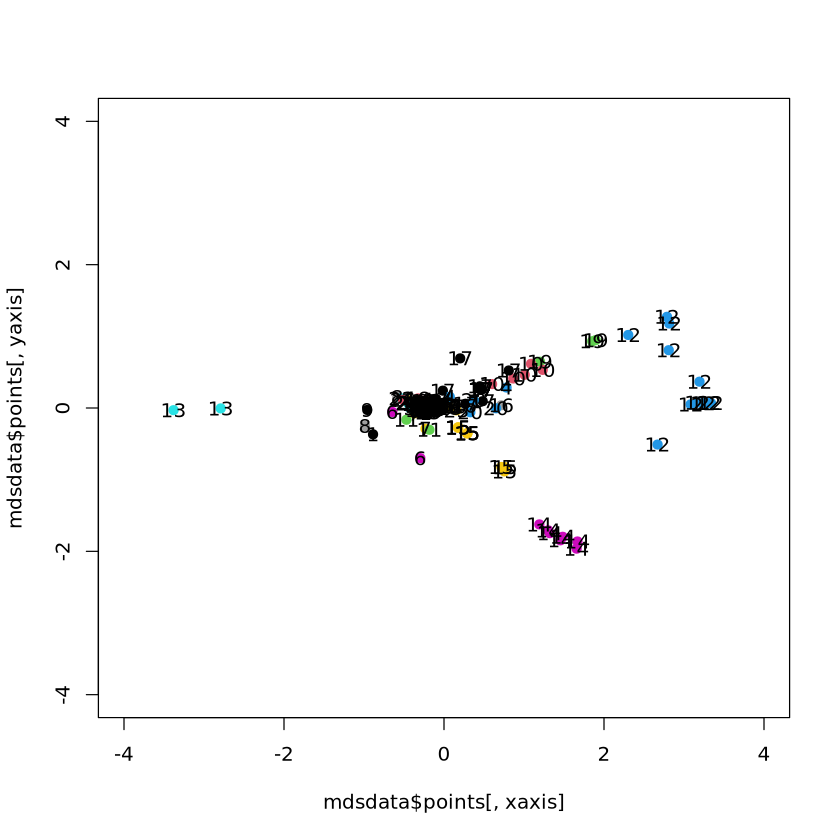

In [2]:
if(!require(NbClust)){
  install.packages("NbClust");library(NbClust)
}
ifname <- "preprocessed_features_OH.csv"
readData <- read.delim(ifname, header=T,sep=",",row.names=1,as.is=TRUE,strip.white=FALSE)
nf1<-dim(readData)[2]
charaCheck<-rep(FALSE,nf1)

#[1]
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
numData<-readData[,charaCheck]

corData<-cor(numData,use="pairwise.complete.obs")
corData[is.na(corData)==TRUE]<-0
ddata<-dist(1-corData)
#[2]
NF<-dim(corData)[2]
mdsdata<-cmdscale(ddata,k=100,eig=TRUE)
cindex<-c("dunn")
clustEst<-NbClust(data = mdsdata$points, diss = NULL, distance = "euclidean", min.nc = 2, max.nc = 100, 
            method = "ward.D2", index = cindex)  #ch  duda
clustEst$Best.nc
plot(clustEst$All.index,type="b",main=cindex)
classData<-clustEst$Best.partition
grpname <- as.factor(classData) 
names(mdsdata)
#[2a]peigen: percent eigen----------------
totaleigen<-sum(mdsdata$eig)
peigen<-mdsdata$eig/totaleigen
neigen<-length(mdsdata$eig)
barplot(peigen[1:50],names.arg=1:50,neigen,ylim=c(0,0.5))
#[2b]-------------------------------------
xaxis<-1
yaxis<-2
par(mfrow=c(1,1))
par(cex=1)
#[2c]
maxiv<-max(c(mdsdata$points[,xaxis],mdsdata$points[,yaxis]))
miniv<-min(c(mdsdata$points[,xaxis],mdsdata$points[,yaxis]))
ivdata<-c(as.integer(miniv)-1,as.integer(maxiv)+1)
plot(mdsdata$points[,xaxis],mdsdata$points[,yaxis],col=grpname,pch=19, cex=1,xlim=ivdata,ylim=ivdata)
text(mdsdata$points[,xaxis],mdsdata$points[,yaxis],labels=grpname)
fn<-paste0("dunn_DataGrp",cindex_newDataSet_del,".csv")
write.csv(grpname,file=fn)


Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"



=== Index: silhouette ===
Best.nc = 2 
Saved plot: silhouette_AllIndex_OH.pdf 
Saved assignment: silhouette_DataGrp_OH.csv 
Saved scatter: silhouette_MDS12_scatter_OH.pdf 

=== Index: dunn ===
Best.nc = 27 
Saved plot: dunn_AllIndex_OH.pdf 
Saved assignment: dunn_DataGrp_OH.csv 
Saved scatter: dunn_MDS12_scatter_OH.pdf 

=== Index: gap ===
Best.nc = 2 
Saved plot: gap_AllIndex_OH.pdf 
Saved assignment: gap_DataGrp_OH.csv 
Saved scatter: gap_MDS12_scatter_OH.pdf 

=== Index: ch ===
Best.nc = 2 
Saved plot: ch_AllIndex_OH.pdf 
Saved assignment: ch_DataGrp_OH.csv 
Saved scatter: ch_MDS12_scatter_OH.pdf 

=== Index: db ===
Best.nc = 3 
Saved plot: db_AllIndex_OH.pdf 
Saved assignment: db_DataGrp_OH.csv 
Saved scatter: db_MDS12_scatter_OH.pdf 

=== Index: ptbiserial ===
Best.nc = 5 
Saved plot: ptbiserial_AllIndex_OH.pdf 
Saved assignment: ptbiserial_DataGrp_OH.csv 
Saved scatter: ptbiserial_MDS12_scatter_OH.pdf 

<U+2705> Completed all indices.


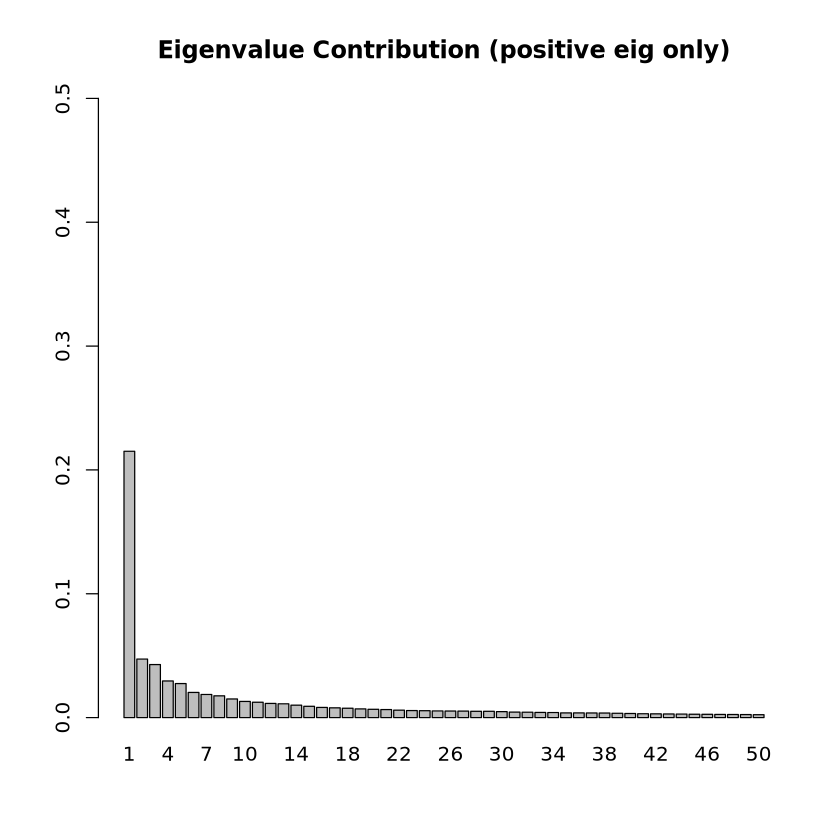

In [3]:
# --- 必要パッケージ ---
if (!require(NbClust)) { install.packages("NbClust"); library(NbClust) }

# --- 入力 ---
set.seed(42)  # 再現性
ifname <- "preprocessed_features_OH.csv"

# --- データ読み込み ---
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1,
                       as.is = TRUE, strip.white = FALSE)

# --- 数値列のみ抽出 ---
nf1 <- ncol(readData)
charaCheck <- rep(FALSE, nf1)
for (i in 1:nf1) {
  charaCheck[i] <- !is.character(readData[, i])
}
numData <- readData[, charaCheck, drop = FALSE]

# --- 相関 -> 距離 -> 線形MDS ---
#   ※ 元の流儀を踏襲（NA→0、1 - cor で距離を作って dist()）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - corData)

NF <- ncol(corData)
mds_k <- min(300, max(1, NF - 1))
mdsdata <- cmdscale(ddata, k = mds_k, eig = TRUE)

# --- 固有値の寄与（参考：正の固有値のみで計算） ---
all_eig <- mdsdata$eig
pos_eig <- all_eig[all_eig > 0]
if (length(pos_eig) > 0) {
  peigen <- pos_eig / sum(pos_eig)
} else {
  peigen <- numeric(0)
}

# 画面に棒グラフ（上位50）を出す（必要なら保存に変更可）
if (length(peigen) > 0) {
  max_dim <- min(50, length(peigen))
  barplot(peigen[1:max_dim], names.arg = 1:max_dim, ylim = c(0, 0.5),
          main = "Eigenvalue Contribution (positive eig only)")
}

# --- 2次元散布（第1-2軸、クラスタ塗り分けは後で） ---
xaxis <- 1; yaxis <- 2
par(mfrow = c(1, 1)); par(cex = 1)

# --- NbClust を指標ごとにループ実行 ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# 出力の共通接頭辞（必要に応じて日付など付けてもOK）
suffix <- "_OH"

for (cindex in index_list) {
  cat("\n=== Index:", cindex, "===\n")
  # NbClust 実行
  clustEst <- tryCatch({
    NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100,
      method = "ward.D2",
      index = cindex
    )
  }, error = function(e) {
    warning(paste("Index", cindex, "failed:", e$message))
    return(NULL)
  })

  if (is.null(clustEst)) next

  # ベスト結果
  best_nc <- clustEst$Best.nc[1]
  classData <- clustEst$Best.partition
  grpname <- as.factor(classData)

  cat("Best.nc =", best_nc, "\n")

  # --- 評価曲線の図を保存 ---
  plot_file <- paste0(cindex, "_AllIndex", suffix, ".pdf")
  pdf(plot_file, width = 7, height = 5)
  plot(clustEst$All.index, type = "b", main = paste0("Index: ", cindex),
       xlab = "k", ylab = "Index value")
  grid()
  dev.off()
  cat("Saved plot:", plot_file, "\n")

  # --- クラスタ割当のCSV出力（手法名ごとにファイル名を変更） ---
  #     例）silhouette_DataGrp_OH.csv
  fn_assign <- paste0(cindex, "_DataGrp", suffix, ".csv")
  write.csv(grpname, file = fn_assign)
  cat("Saved assignment:", fn_assign, "\n")

  # --- 2次元プロットをクラスタ色で保存（任意） ---
  scat_file <- paste0(cindex, "_MDS12_scatter", suffix, ".pdf")
  pdf(scat_file, width = 6, height = 6)
  maxiv <- max(c(mdsdata$points[, xaxis], mdsdata$points[, yaxis]))
  miniv <- min(c(mdsdata$points[, xaxis], mdsdata$points[, yaxis]))
  ivdata <- c(as.integer(miniv) - 1, as.integer(maxiv) + 1)
  plot(mdsdata$points[, xaxis], mdsdata$points[, yaxis],
       col = grpname, pch = 19, cex = 0.8, xlim = ivdata, ylim = ivdata,
       main = paste0("MDS (", cindex, ", k=", best_nc, ")"),
       xlab = paste0("Dim ", xaxis), ylab = paste0("Dim ", yaxis))
  # ※ ラベルは点が多いと読みにくいのでコメントアウト
  # text(mdsdata$points[, xaxis], mdsdata$points[, yaxis], labels = grpname, cex = 0.6, pos = 3)
  dev.off()
  cat("Saved scatter:", scat_file, "\n")
}

cat("\n✅ Completed all indices.\n")


Loading required package: ggplot2

Loading required package: ggrepel

Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."
Warning message:
"ggrepel: 357 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."
Warning message:
"ggrepel: 357 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."
Warning message:
"ggrepel: 359 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


<U+2705> Saved plot:
  - MDS12_scatter_OH_20250821_1337.png 
  - MDS12_scatter_OH_20250821_1337.pdf 


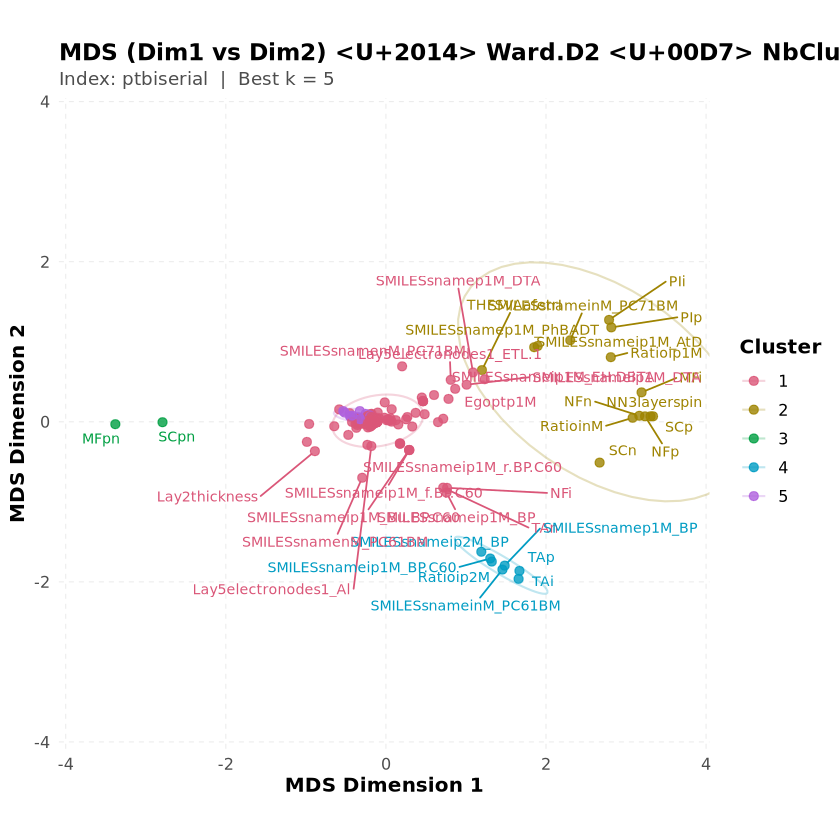

In [4]:
# --- 追加パッケージ（未インストールなら自動） ---
if (!require(ggplot2)) install.packages("ggplot2"); library(ggplot2)
if (!require(ggrepel)) install.packages("ggrepel"); library(ggrepel)

# ==== ここから “見栄え良い図” セクション（既存の base::plot/text を置き換え） ====

# MDS第1-2軸のデータフレーム化
df_plot <- data.frame(
  MDS1    = mdsdata$points[, 1],
  MDS2    = mdsdata$points[, 2],
  Cluster = grpname,
  ID      = rownames(mdsdata$points)
)

# 軸スケールを揃える（等尺）ための余白設定
rng <- range(c(df_plot$MDS1, df_plot$MDS2), na.rm = TRUE)
pad <- diff(rng) * 0.05
lims <- c(min(rng) - pad, max(rng) + pad)

# タイムスタンプ & 出力ファイル名（OHタグ）
ts_tag <- format(Sys.time(), "%Y%m%d_%H%M")
file_png <- paste0("MDS12_scatter_OH_", ts_tag, ".png")
file_pdf <- paste0("MDS12_scatter_OH_", ts_tag, ".pdf")

p <- ggplot(df_plot, aes(x = MDS1, y = MDS2, color = Cluster)) +
  # クラスタ楕円（95%）
  stat_ellipse(aes(group = Cluster), type = "norm", level = 0.95, linewidth = 0.6, alpha = 0.25) +
  # 点（半透明・少し大きめ）
  geom_point(size = 2.2, alpha = 0.8) +
  # ラベル（重なり回避）※ラベルが多い場合は次の行をコメントアウト推奨
  ggrepel::geom_text_repel(aes(label = ID), size = 3, max.overlaps = 100,
                           box.padding = 0.3, point.padding = 0.2, show.legend = FALSE) +
  # 等尺表示＆余白
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  # カラースキーム（必要なら好みで変更可）
  scale_color_hue(h = c(0, 360), l = 55, c = 90) +
  # 軸とタイトル
  labs(
    title = "MDS (Dim1 vs Dim2) — Ward.D2 × NbClust",
    subtitle = paste0("Index: ", cindex, "  |  Best k = ", clustEst$Best.nc[1]),
    x = "MDS Dimension 1", y = "MDS Dimension 2", color = "Cluster"
  ) +
  # ミニマルなテーマを微調整
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.major = element_line(linewidth = 0.3, linetype = "dashed"),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14, margin = margin(b = 4)),
    plot.subtitle = element_text(size = 11, colour = "grey30"),
    legend.position = "right",
    legend.title = element_text(face = "bold")
  )

# 画面表示
print(p)

# 高解像度保存（PNG: 300dpi / PDF: ベクター）
ggsave(filename = file_png, plot = p, width = 7, height = 6, dpi = 300)
ggsave(filename = file_pdf, plot = p, width = 7, height = 6, device = cairo_pdf)
cat("✅ Saved plot:\n  -", file_png, "\n  -", file_pdf, "\n")

# ==== ここまで ====


Loading required package: scales



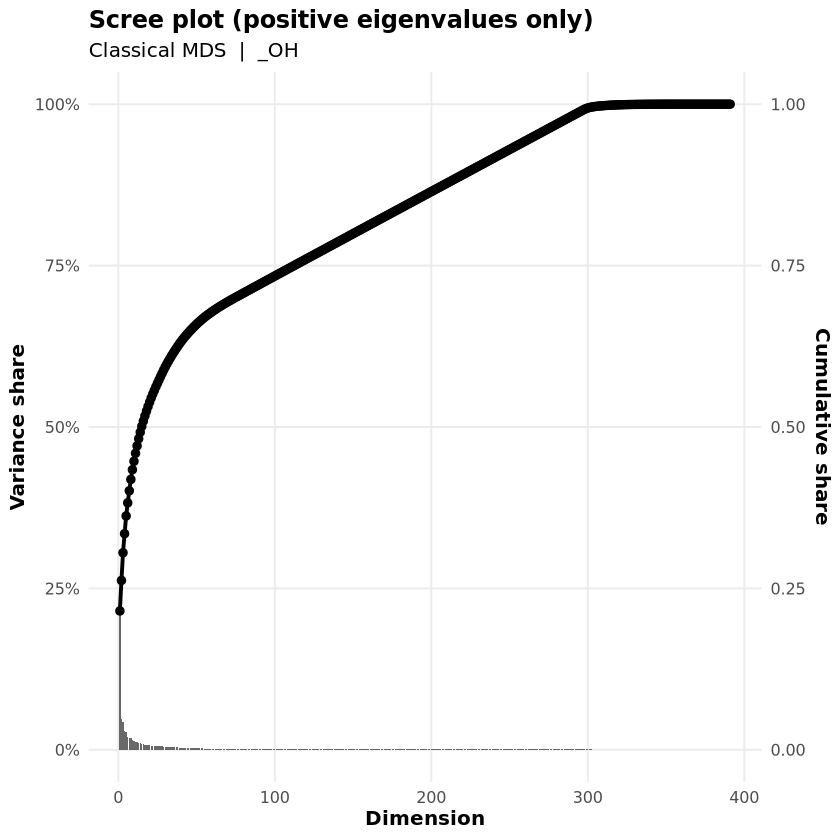

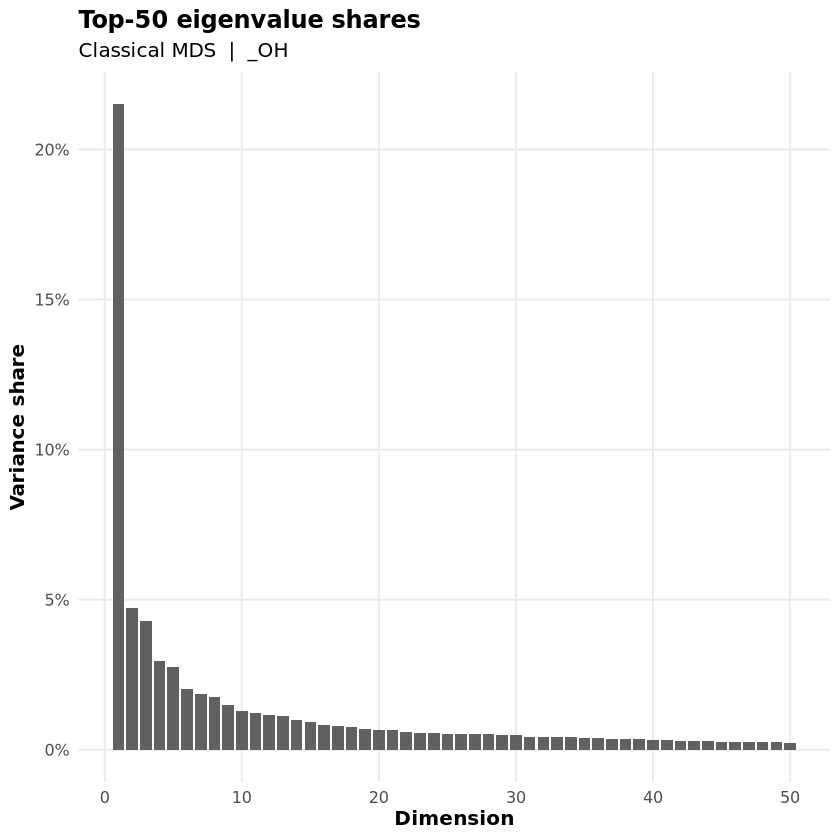

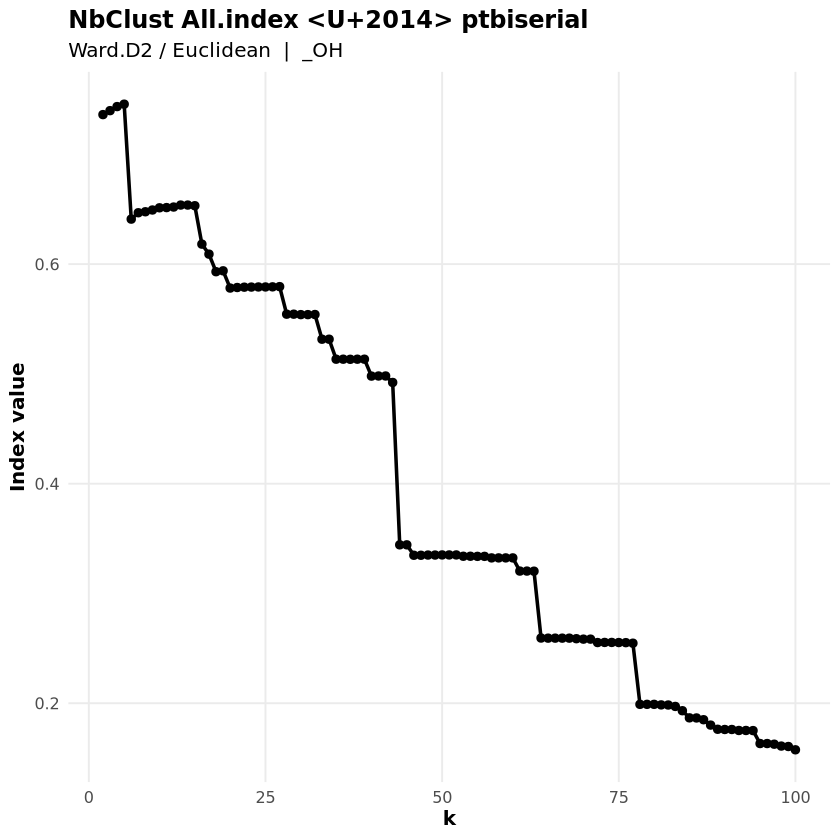

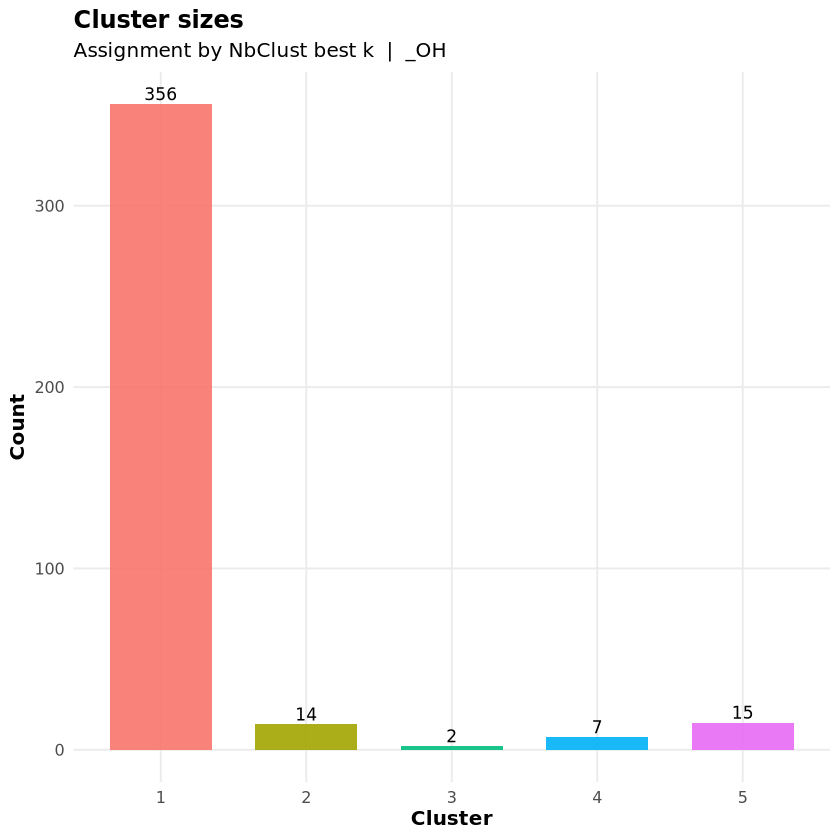

In [5]:
# ==== 追加のきれいな図たち（棒・折れ線等） ====
if (!require(ggplot2)) install.packages("ggplot2"); library(ggplot2)
if (!require(scales))  install.packages("scales");  library(scales)

# 出力設定
suffix  <- if (exists("suffix")) suffix else "OH"
out_dir <- if (exists("out_dir")) out_dir else paste0("figs_", suffix)
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag  <- format(Sys.time(), "%Y%m%d_%H%M")

## 1) 固有値：スクリープロット（棒 + 累積折れ線, 正の固有値のみ）
eig_all <- mdsdata$eig
eig_pos <- eig_all[eig_all > 0]
df_eig  <- data.frame(
  Dim = seq_along(eig_pos),
  Eig = as.numeric(eig_pos)
)
df_eig$Prop <- df_eig$Eig / sum(df_eig$Eig)
df_eig$Cum  <- cumsum(df_eig$Prop)

p_scree <- ggplot(df_eig, aes(x = Dim, y = Prop)) +
  geom_col(width = 0.85, alpha = 0.9) +
  geom_line(aes(y = Cum), linewidth = 1.1) +
  geom_point(aes(y = Cum), size = 2) +
  scale_y_continuous(labels = percent_format(accuracy = 1),
                     sec.axis = sec_axis(~ ., name = "Cumulative share")) +
  labs(title = "Scree plot (positive eigenvalues only)",
       subtitle = paste0("Classical MDS  |  ", suffix),
       x = "Dimension", y = "Variance share") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        axis.title = element_text(face = "bold"),
        plot.title = element_text(face = "bold"))
print(p_scree)

ggsave(file.path(out_dir, paste0("MDS_scree_", suffix, "_", ts_tag, ".png")),
       p_scree, width = 7, height = 5, dpi = 300)
ggsave(file.path(out_dir, paste0("MDS_scree_", suffix, "_", ts_tag, ".pdf")),
       p_scree, width = 7, height = 5, device = cairo_pdf)

## 2) 固有値トップ50の棒グラフ
topN <- min(50, nrow(df_eig))
df_eig50 <- df_eig[1:topN, , drop = FALSE]
p_bar50 <- ggplot(df_eig50, aes(x = Dim, y = Prop)) +
  geom_col(width = 0.85, alpha = 0.95) +
  labs(title = paste0("Top-", topN, " eigenvalue shares"),
       subtitle = paste0("Classical MDS  |  ", suffix),
       x = "Dimension", y = "Variance share") +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        axis.title = element_text(face = "bold"),
        plot.title = element_text(face = "bold"))
print(p_bar50)

ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix, "_", ts_tag, ".png")),
       p_bar50, width = 7, height = 5, dpi = 300)
ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix, "_", ts_tag, ".pdf")),
       p_bar50, width = 7, height = 5, device = cairo_pdf)

## 3) NbClust の All.index をきれいに
# clustEst$All.index は名前付きベクトルのことが多いので k 軸を整える
if (exists("clustEst") && !is.null(clustEst$All.index)) {
  idx_vals <- as.numeric(clustEst$All.index)
  k_labels <- names(clustEst$All.index)
  if (is.null(k_labels) || any(k_labels == "")) {
    k_seq <- seq_along(idx_vals)
  } else {
    k_seq <- as.numeric(k_labels)
    if (any(is.na(k_seq))) k_seq <- seq_along(idx_vals)
  }
  df_idx <- data.frame(k = k_seq, value = idx_vals)

  p_idx <- ggplot(df_idx, aes(x = k, y = value)) +
    geom_line(linewidth = 1) +
    geom_point(size = 2) +
    labs(title = paste0("NbClust All.index — ", cindex),
         subtitle = paste0("Ward.D2 / Euclidean  |  ", suffix),
         x = "k", y = "Index value") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  print(p_idx)

  ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix, "_", ts_tag, ".png")),
         p_idx, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix, "_", ts_tag, ".pdf")),
         p_idx, width = 7, height = 5, device = cairo_pdf)
}

## 4) クラスターサイズの棒グラフ
if (exists("grpname")) {
  df_size <- as.data.frame(table(Cluster = grpname))
  p_size <- ggplot(df_size, aes(x = Cluster, y = Freq, fill = Cluster)) +
    geom_col(width = 0.7, alpha = 0.9, show.legend = FALSE) +
    geom_text(aes(label = Freq), vjust = -0.3, size = 3.6) +
    labs(title = "Cluster sizes",
         subtitle = paste0("Assignment by NbClust best k  |  ", suffix),
         x = "Cluster", y = "Count") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  print(p_size)

  ggsave(file.path(out_dir, paste0("Cluster_sizes_", suffix, "_", ts_tag, ".png")),
         p_size, width = 6.5, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", suffix, "_", ts_tag, ".pdf")),
         p_size, width = 6.5, height = 5, device = cairo_pdf)
}
# ==== ここまで ====


In [6]:
# --- 必要パッケージ ---
if (!require(NbClust)) { install.packages("NbClust"); library(NbClust) }
if (!require(ggplot2)) { install.packages("ggplot2"); library(ggplot2) }
if (!require(ggrepel)) { install.packages("ggrepel"); library(ggrepel) }
if (!require(scales))  { install.packages("scales");  library(scales) }

# --- 入力 ---
set.seed(42)  # 再現性
ifname <- "preprocessed_features_OH.csv"

# --- 出力設定 ---
suffix  <- "_OH"                                # ← FPにしたい時は "_FP"
suffix_tag <- sub("^_", "", suffix)             # "OH" だけを取り出す
out_dir <- paste0("figs_", suffix_tag)          # 例: figs_OH
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag  <- format(Sys.time(), "%Y%m%d_%H%M")

# --- データ読み込み ---
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1,
                       as.is = TRUE, strip.white = FALSE)

# --- 数値列のみ抽出 ---
nf1 <- ncol(readData)
charaCheck <- rep(FALSE, nf1)
for (i in 1:nf1) {
  charaCheck[i] <- !is.character(readData[, i])
}
numData <- readData[, charaCheck, drop = FALSE]

# --- 相関 -> 距離 -> 線形MDS ---
#   ※ 元コード準拠（NA→0、1 - cor）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - corData)

NF <- ncol(corData)
mds_k <- min(300, max(1, NF - 1))
mdsdata <- cmdscale(ddata, k = mds_k, eig = TRUE)

# --- 固有値の寄与（正の固有値のみ） ---
all_eig <- mdsdata$eig
pos_eig <- all_eig[all_eig > 0]
peigen  <- if (length(pos_eig) > 0) pos_eig / sum(pos_eig) else numeric(0)

# ====== ここから “全体で1回” のスタイリッシュ図（スクリープロットほか） ======
if (length(peigen) > 0) {
  df_eig <- data.frame(
    Dim  = seq_along(pos_eig),
    Eig  = as.numeric(pos_eig)
  )
  df_eig$Prop <- df_eig$Eig / sum(df_eig$Eig)
  df_eig$Cum  <- cumsum(df_eig$Prop)

  # 1) スクリープロット（棒 + 累積線）
  p_scree <- ggplot(df_eig, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.9) +
    geom_line(aes(y = Cum), linewidth = 1.1) +
    geom_point(aes(y = Cum), size = 2) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       sec.axis = sec_axis(~ ., name = "Cumulative share")) +
    labs(title = "Scree plot (positive eigenvalues only)",
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".png")),
         p_scree, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scree, width = 7, height = 5, device = cairo_pdf)

  # 2) 固有値トップ50の棒グラフ
  topN <- min(50, nrow(df_eig))
  df_eig50 <- df_eig[1:topN, , drop = FALSE]
  p_bar50 <- ggplot(df_eig50, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.95) +
    labs(title = paste0("Top-", topN, " eigenvalue shares"),
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".png")),
         p_bar50, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_bar50, width = 7, height = 5, device = cairo_pdf)
} else {
  warning("No positive eigenvalues; scree/top50 plots skipped.")
}
# ====== ここまで “全体で1回” ======

# --- NbClust を指標ごとにループ実行 ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

for (cindex in index_list) {
  cat("\n=== Index:", cindex, "===\n")
  # NbClust 実行
  clustEst <- tryCatch({
    NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100,
      method = "ward.D2",
      index = cindex
    )
  }, error = function(e) {
    warning(paste("Index", cindex, "failed:", e$message))
    return(NULL)
  })
  if (is.null(clustEst)) next

  # ベスト結果
  best_nc  <- clustEst$Best.nc[1]
  classData <- clustEst$Best.partition
  grpname   <- as.factor(classData)
  cat("Best.nc =", best_nc, "\n")

  # --- クラスタ割当CSV（従来形式）
  fn_assign <- paste0(cindex, "_DataGrp", suffix, ".csv")
  write.csv(grpname, file = file.path(out_dir, fn_assign))

  # ====== ここから “各 cindex ごと” のスタイリッシュ図 ======

  ## (a) MDS 1-2 散布図（クラスタ色・楕円）
  df_plot <- data.frame(
    MDS1    = mdsdata$points[, 1],
    MDS2    = mdsdata$points[, 2],
    Cluster = grpname,
    ID      = rownames(mdsdata$points)
  )
  rng <- range(c(df_plot$MDS1, df_plot$MDS2), na.rm = TRUE)
  pad <- diff(rng) * 0.05
  lims <- c(min(rng) - pad, max(rng) + pad)

  p_scatter <- ggplot(df_plot, aes(x = MDS1, y = MDS2, color = Cluster)) +
    stat_ellipse(aes(group = Cluster), type = "norm", level = 0.95,
                 linewidth = 0.6, alpha = 0.25) +
    geom_point(size = 2.2, alpha = 0.8) +
    # ラベルが多い場合は下行をコメントアウトしてOK
    # ggrepel::geom_text_repel(aes(label = ID), size = 3, max.overlaps = 100,
    #                          box.padding = 0.3, point.padding = 0.2, show.legend = FALSE) +
    coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
    scale_color_hue(h = c(0, 360), l = 55, c = 90) +
    labs(title = "MDS (Dim1 vs Dim2) — Ward.D2 × NbClust",
         subtitle = paste0("Index: ", cindex, "  |  Best k = ", best_nc,
                           "  |  ", suffix_tag),
         x = "MDS Dimension 1", y = "MDS Dimension 2", color = "Cluster") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major = element_line(linewidth = 0.3, linetype = "dashed"),
          panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 14, margin = margin(b = 4)),
          plot.subtitle = element_text(size = 11, colour = "grey30"),
          legend.position = "right",
          legend.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_scatter, width = 7, height = 6, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scatter, width = 7, height = 6, device = cairo_pdf)

  ## (b) NbClust All.index 曲線
  if (!is.null(clustEst$All.index)) {
    idx_vals  <- as.numeric(clustEst$All.index)
    k_labels  <- names(clustEst$All.index)
    k_seq <- if (is.null(k_labels) || any(k_labels == "")) seq_along(idx_vals) else suppressWarnings(as.numeric(k_labels))
    if (any(is.na(k_seq))) k_seq <- seq_along(idx_vals)

    df_idx <- data.frame(k = k_seq, value = idx_vals)
    p_idx <- ggplot(df_idx, aes(x = k, y = value)) +
      geom_line(linewidth = 1) +
      geom_point(size = 2) +
      labs(title = paste0("NbClust All.index — ", cindex),
           subtitle = paste0("Ward.D2 / Euclidean  |  ", suffix_tag),
           x = "k", y = "Index value") +
      theme_minimal(base_size = 12) +
      theme(panel.grid.minor = element_blank(),
            axis.title = element_text(face = "bold"),
            plot.title = element_text(face = "bold"))
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
           p_idx, width = 7, height = 5, dpi = 300)
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
           p_idx, width = 7, height = 5, device = cairo_pdf)
  }

  ## (c) クラスターサイズ棒グラフ
  df_size <- as.data.frame(table(Cluster = grpname))
  p_size <- ggplot(df_size, aes(x = Cluster, y = Freq, fill = Cluster)) +
    geom_col(width = 0.7, alpha = 0.9, show.legend = FALSE) +
    geom_text(aes(label = Freq), vjust = -0.3, size = 3.6) +
    labs(title = "Cluster sizes",
         subtitle = paste0("Assignment by NbClust best k  |  ", suffix_tag),
         x = "Cluster", y = "Count") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_size, width = 6.5, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_size, width = 6.5, height = 5, device = cairo_pdf)

  # ====== ここまで 各 cindex ごと ======

  cat("Saved: ", cindex, " figures & assignment under ", normalizePath(out_dir), "\n")
}

cat("\n✅ Completed all indices. Figures are under: ", normalizePath(out_dir), "\n")


Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"


In [8]:
# --- 必要パッケージ ---
if (!require(NbClust)) { install.packages("NbClust"); library(NbClust) }
if (!require(ggplot2)) { install.packages("ggplot2"); library(ggplot2) }
if (!require(ggrepel)) { install.packages("ggrepel"); library(ggrepel) }
if (!require(scales))  { install.packages("scales");  library(scales) }
if (!require(MASS))    { install.packages("MASS");    library(MASS) }     # isoMDS 用（必要なら）
if (!require(mclust))  { install.packages("mclust");  library(mclust) }   # ARI

# --- 入力 ---
set.seed(42)  # 再現性
ifname <- "preprocessed_features_OH.csv"

# --- 出力設定（OH/FP 切替は suffix を変更） ---
suffix     <- "_OH"                               # ← "_FP" に変えるだけでFP版
suffix_tag <- sub("^_", "", suffix)               # "OH" など
out_dir    <- paste0("figs_", suffix_tag)         # 例: figs_OH
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag     <- format(Sys.time(), "%Y%m%d_%H%M")

# --- データ読み込み ---
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1,
                       as.is = TRUE, strip.white = FALSE)

# --- 数値列のみ抽出 ---
is_num <- vapply(readData, function(x) !is.character(x), logical(1))
numData <- readData[, is_num, drop = FALSE]

# --- 相関 -> 距離 -> 古典MDS ---
#   ※ 元コード準拠（NA→0、1 - cor）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - corData)

NF <- ncol(corData)
mds_k <- min(300, max(1, NF - 1))
mdsdata <- cmdscale(ddata, k = mds_k, eig = TRUE)

# --- 固有値寄与（全基準＆正の固有値基準） + CSV保存 ---
pct <- function(x) sprintf("%.2f%%", 100 * x)

eig_all <- mdsdata$eig
S_all   <- sum(eig_all)
share_all <- eig_all / S_all

eig_pos <- eig_all[eig_all > 0]
S_pos   <- sum(eig_pos)
share_pos <- rep(NA_real_, length(eig_all))
share_pos[eig_all > 0] <- eig_all[eig_all > 0] / S_pos

cum_all <- cumsum(share_all)
cum_pos <- {
  tmp <- share_pos; tmp[is.na(tmp)] <- 0; cumsum(tmp)
}

# 第1〜3軸のレポート（全基準）
p1_all <- share_all[1]; p2_all <- share_all[2]
cum3_all <- sum(share_all[1:min(3, length(share_all))], na.rm = TRUE)
cat("【全固有値基準】第1:", pct(p1_all), "  第2:", pct(p2_all),
    "  1–2合計:", pct(p1_all + p2_all), "  1–3累積:", pct(cum3_all), "\n")

# CSV出力（寄与一覧）
df_eig_out <- data.frame(
  Dim           = seq_along(eig_all),
  Eigenvalue    = eig_all,
  Share_all     = share_all,
  Share_pos     = share_pos,
  CumShare_all  = cum_all,
  CumShare_pos  = cum_pos
)
write.csv(df_eig_out, file.path(out_dir, paste0("MDS_eigen_contributions_", suffix_tag, "_", ts_tag, ".csv")),
          row.names = FALSE)

# ====== “全体で1回” のスタイリッシュ図（スクリープロット & Top50） ======
if (length(eig_pos) > 0) {
  df_eig <- data.frame(
    Dim  = seq_along(eig_pos),
    Eig  = as.numeric(eig_pos)
  )
  df_eig$Prop <- df_eig$Eig / sum(df_eig$Eig)
  df_eig$Cum  <- cumsum(df_eig$Prop)

  # 1) スクリープロット（棒 + 累積線）
  p_scree <- ggplot(df_eig, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.9) +
    geom_line(aes(y = Cum), linewidth = 1.1) +
    geom_point(aes(y = Cum), size = 2) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       sec.axis = sec_axis(~ ., name = "Cumulative share")) +
    labs(title = "Scree plot (positive eigenvalues only)",
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".png")),
         p_scree, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scree, width = 7, height = 5, device = cairo_pdf)

  # 2) 固有値トップ50の棒グラフ
  topN <- min(50, nrow(df_eig))
  df_eig50 <- df_eig[1:topN, , drop = FALSE]
  p_bar50 <- ggplot(df_eig50, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.95) +
    labs(title = paste0("Top-", topN, " eigenvalue shares"),
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".png")),
         p_bar50, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_bar50, width = 7, height = 5, device = cairo_pdf)
} else {
  warning("No positive eigenvalues; scree/top50 plots skipped.")
}

# ====== NbClust：指標ごと ======
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

for (cindex in index_list) {
  cat("\n=== Index:", cindex, "===\n")
  clustEst <- tryCatch({
    NbClust(
      data = mdsdata$points, diss = NULL, distance = "euclidean",
      min.nc = 2, max.nc = 100, method = "ward.D2", index = cindex
    )
  }, error = function(e) { warning(paste("Index", cindex, "failed:", e$message)); NULL })
  if (is.null(clustEst)) next

  best_nc  <- clustEst$Best.nc[1]
  grpname  <- as.factor(clustEst$Best.partition)
  cat("Best.nc =", best_nc, "\n")

  # 割当CSV
  fn_assign <- paste0(cindex, "_DataGrp", suffix, ".csv")
  write.csv(grpname, file = file.path(out_dir, fn_assign))

  # (a) MDS 1-2 散布図（楕円つき）
  df_plot <- data.frame(
    MDS1    = mdsdata$points[, 1],
    MDS2    = mdsdata$points[, 2],
    Cluster = grpname,
    ID      = rownames(mdsdata$points)
  )
  rng <- range(c(df_plot$MDS1, df_plot$MDS2), na.rm = TRUE)
  pad <- diff(rng) * 0.05; lims <- c(min(rng) - pad, max(rng) + pad)

  p_scatter <- ggplot(df_plot, aes(x = MDS1, y = MDS2, color = Cluster)) +
    stat_ellipse(aes(group = Cluster), type = "norm", level = 0.95,
                 linewidth = 0.6, alpha = 0.25) +
    geom_point(size = 2.2, alpha = 0.8) +
    # ggrepel::geom_text_repel(aes(label = ID), size = 3, max.overlaps = 100,
    #                          box.padding = 0.3, point.padding = 0.2, show.legend = FALSE) +
    coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
    scale_color_hue(h = c(0, 360), l = 55, c = 90) +
    labs(title = "MDS (Dim1 vs Dim2) — Ward.D2 × NbClust",
         subtitle = paste0("Index: ", cindex, "  |  Best k = ", best_nc, "  |  ", suffix_tag),
         x = "MDS Dimension 1", y = "MDS Dimension 2", color = "Cluster") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major = element_line(linewidth = 0.3, linetype = "dashed"),
          panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 14, margin = margin(b = 4)),
          plot.subtitle = element_text(size = 11, colour = "grey30"),
          legend.position = "right",
          legend.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_scatter, width = 7, height = 6, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scatter, width = 7, height = 6, device = cairo_pdf)

  # (b) NbClust All.index 曲線
  if (!is.null(clustEst$All.index)) {
    idx_vals  <- as.numeric(clustEst$All.index)
    k_labels  <- names(clustEst$All.index)
    k_seq <- if (is.null(k_labels) || any(k_labels == "")) seq_along(idx_vals) else suppressWarnings(as.numeric(k_labels))
    if (any(is.na(k_seq))) k_seq <- seq_along(idx_vals)

    df_idx <- data.frame(k = k_seq, value = idx_vals)
    p_idx <- ggplot(df_idx, aes(x = k, y = value)) +
      geom_line(linewidth = 1) +
      geom_point(size = 2) +
      labs(title = paste0("NbClust All.index — ", cindex),
           subtitle = paste0("Ward.D2 / Euclidean  |  ", suffix_tag),
           x = "k", y = "Index value") +
      theme_minimal(base_size = 12) +
      theme(panel.grid.minor = element_blank(),
            axis.title = element_text(face = "bold"),
            plot.title = element_text(face = "bold"))
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
           p_idx, width = 7, height = 5, dpi = 300)
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
           p_idx, width = 7, height = 5, device = cairo_pdf)
  }

  # (c) クラスタサイズ棒グラフ
  df_size <- as.data.frame(table(Cluster = grpname))
  p_size <- ggplot(df_size, aes(x = Cluster, y = Freq, fill = Cluster)) +
    geom_col(width = 0.7, alpha = 0.9, show.legend = FALSE) +
    geom_text(aes(label = Freq), vjust = -0.3, size = 3.6) +
    labs(title = "Cluster sizes",
         subtitle = paste0("Assignment by NbClust best k  |  ", suffix_tag),
         x = "Cluster", y = "Count") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_size, width = 6.5, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_size, width = 6.5, height = 5, device = cairo_pdf)

  cat("Saved: ", cindex, " figures & assignment under ", normalizePath(out_dir), "\n")
}

# ====== top3 vs cumeig（≥0.8）の両条件でクラスタリングし、ARIを計算 ======
eigtarget <- 0.80
contrib_pos <- if (length(eig_pos) > 0) eig_pos / sum(eig_pos) else numeric(0)
k_cumeig <- if (length(contrib_pos) > 0) which(cumsum(contrib_pos) >= eigtarget)[1] else 3
if (is.na(k_cumeig) || k_cumeig < 2) k_cumeig <- 3

coords_list <- list(
  top3   = mdsdata$points[, 1:min(3, ncol(mdsdata$points)), drop = FALSE],
  cumeig = mdsdata$points[, 1:min(k_cumeig, ncol(mdsdata$points)), drop = FALSE]
)

# 座標CSV（条件ごと）保存
for (cond in names(coords_list)) {
  write.csv(coords_list[[cond]],
            file.path(out_dir, paste0("MDScoords_", cond, "_", suffix_tag, "_", ts_tag, ".csv")))
}

index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")
assignments <- list()

for (cond in names(coords_list)) {
  X <- coords_list[[cond]]
  rownames(X) <- rownames(mdsdata$points)

  for (cindex in index_list) {
    clustEst <- tryCatch({
      NbClust(data = X, diss = NULL, distance = "euclidean",
              min.nc = 2, max.nc = 100, method = "ward.D2", index = cindex)
    }, error = function(e) { warning(paste("failed:", cond, cindex, e$message)); NULL })
    if (is.null(clustEst)) next

    grp <- as.factor(clustEst$Best.partition)

    # 割当て保存
    fn_assign2 <- paste0("ClusterAssign_", cond, "_", cindex, "_",
                         suffix_tag, "_", ts_tag, ".csv")
    write.csv(data.frame(Variable = names(grp), Cluster = grp),
              file.path(out_dir, fn_assign2), row.names = FALSE)

    assignments[[paste(cond, cindex, sep = "_")]] <- grp
  }
}

# ARI: top3 と cumeig の一致度
ari_rows <- lapply(index_list, function(ix) {
  a <- assignments[[paste0("top3_", ix)]]
  b <- assignments[[paste0("cumeig_", ix)]]
  ari <- if (!is.null(a) && !is.null(b)) mclust::adjustedRandIndex(a, b) else NA_real_
  data.frame(Index = ix, ARI_top3_vs_cumeig = ari)
})
df_ari <- do.call(rbind, ari_rows)
write.csv(df_ari, file.path(out_dir, paste0("ARI_top3_vs_cumeig_", suffix_tag, "_", ts_tag, ".csv")),
          row.names = FALSE)
print(df_ari)

cat("\n✅ All done. Outputs under: ", normalizePath(out_dir), "\n")


Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"


<U+3010><U+5168><U+56FA><U+6709><U+5024><U+57FA><U+6E96><U+3011><U+7B2C>1: 21.51%   <U+7B2C>2: 4.73%   1<U+2013>2<U+5408><U+8A08>: 26.23%   1<U+2013>3<U+7D2F><U+7A4D>: 30.52% 

=== Index: silhouette ===
Best.nc = 2 
Saved:  silhouette  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 

=== Index: dunn ===
Best.nc = 27 


Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_path()`)."
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_path()`)."


Saved:  dunn  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 

=== Index: gap ===
Best.nc = 2 
Saved:  gap  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 

=== Index: ch ===
Best.nc = 2 
Saved:  ch  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 

=== Index: db ===
Best.nc = 3 
Saved:  db  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 

=== Index: ptbiserial ===
Best.nc = 5 


Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."
Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."


Saved:  ptbiserial  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 
       Index ARI_top3_vs_cumeig
1 silhouette        0.971520574
2       dunn        0.651992237
3        gap        0.971520574
4         ch        0.009831725
5         db        0.010704889
6 ptbiserial        0.465788149

<U+2705> All done. Outputs under:  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH 


Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH/MDS_vars_points_Dim1v2_OH_20250826_1337.png

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH/MDS_vars_points_Dim1v2_OH_20250826_1337.pdf



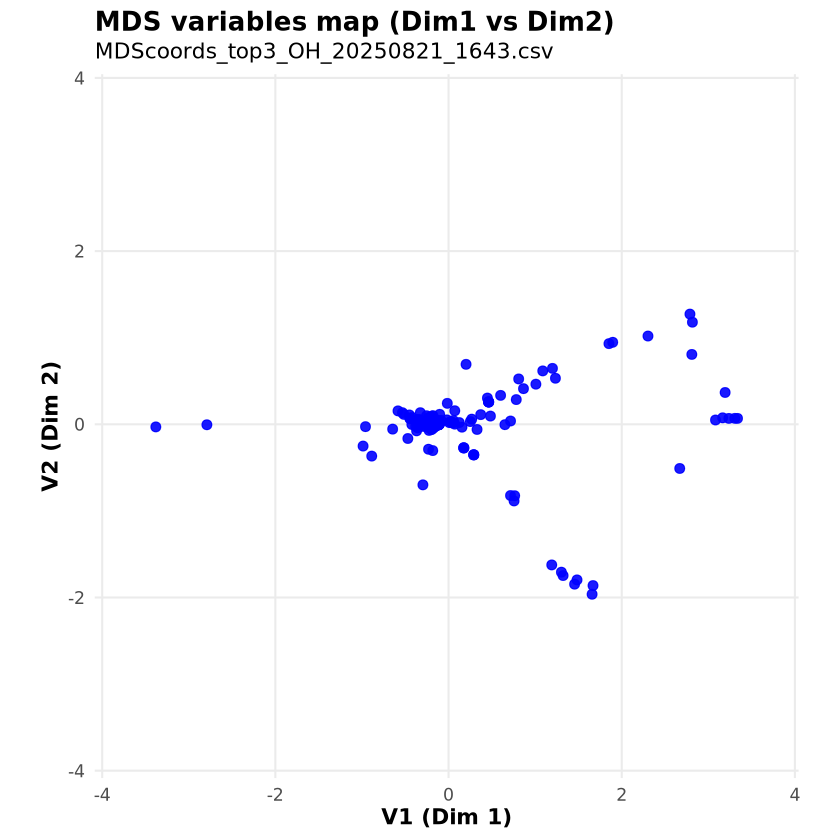

In [17]:
# --- 必要パッケージ ---
if (!require(ggplot2)) install.packages("ggplot2"); library(ggplot2)
if (!require(ggrepel)) install.packages("ggrepel"); library(ggrepel)

# --- 入力（ローカル推奨。URLは/raw/に差し替えが必要） ---
infile <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH/MDScoords_top3_OH_20250821_1643.csv"

# --- 出力先 ---
out_dir <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_OH"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag <- format(Sys.time(), "%Y%m%d_%H%M")

# ========== 安全読み込み（行名にしない、重複対策） ==========
df_raw <- read.csv(infile, header = TRUE, stringsAsFactors = FALSE, check.names = FALSE)

# write.csv(row.names=TRUE) 由来の先頭列 "X" を変数名として扱う
# そうでなければ、先頭列が文字型なら変数名列とみなす
if ("X" %in% names(df_raw)) {
  var_col <- as.character(df_raw[["X"]])
  df <- df_raw[, setdiff(names(df_raw), "X"), drop = FALSE]
} else if (is.character(df_raw[[1]]) || is.factor(df_raw[[1]])) {
  var_col <- as.character(df_raw[[1]])
  df <- df_raw[, -1, drop = FALSE]
} else {
  # 変数名列が無い場合は行番号を名前にする
  var_col <- paste0("Var", seq_len(nrow(df_raw)))
  df <- df_raw
}

# 変数名の重複を一意化
var_col <- make.unique(var_col, sep = "_dup")

# ========== 軸列の自動検出 ==========
cand_pairs <- list(
  c("V1","V2"),                 # ← ご指定を最優先
  c("MDS1","MDS2"),
  c("Dim1","Dim2"),
  c("Dimension1","Dimension2"),
  c("Axis1","Axis2"),
  c("PC1","PC2")
)

pick_cols <- NULL
for (p in cand_pairs) {
  if (all(p %in% colnames(df))) { pick_cols <- p; break }
}
if (is.null(pick_cols)) {
  # 数値列の先頭2本を使う
  num_cols <- names(df)[vapply(df, is.numeric, logical(1))]
  if (length(num_cols) < 2) stop("第1・第2軸に相当する数値列が見つかりません。")
  pick_cols <- num_cols[1:2]
  message("既知の列名が見つからないため、数値列の先頭2列を使用: ",
          paste(pick_cols, collapse = ", "))
}

xcol <- pick_cols[1]; ycol <- pick_cols[2]

plot_df <- data.frame(
  Var = var_col,
  X   = df[[xcol]],
  Y   = df[[ycol]],
  stringsAsFactors = FALSE
)
plot_df <- na.omit(plot_df)

# スケール調整（正方表示）
rng <- range(c(plot_df$X, plot_df$Y), na.rm = TRUE)
pad <- diff(rng) * 0.05; lims <- c(min(rng) - pad, max(rng) + pad)

# --- プロット作成（ラベルなし、点のみ） ---
p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.4, alpha = 0.9, color = "blue") +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", margin = margin(b = 4))
  ) +
  labs(
    title = "MDS variables map (Dim1 vs Dim2)",
    subtitle = basename(infile),
    x = paste0(xcol, " (Dim 1)"),
    y = paste0(ycol, " (Dim 2)")
  )

# --- コンソールに表示 ---
print(p)

# --- 保存（必要なら） ---
png_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".png"))
pdf_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".pdf"))
ggsave(png_file, p, width = 7.5, height = 6.5, dpi = 300)
ggsave(pdf_file, p, width = 7.5, height = 6.5, device = cairo_pdf)


message("Saved: ", png_file)
message("Saved: ", pdf_file)


Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP/MDS_vars_points_Dim1v2_FP_20250826_1339.png

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP/MDS_vars_points_Dim1v2_FP_20250826_1339.pdf



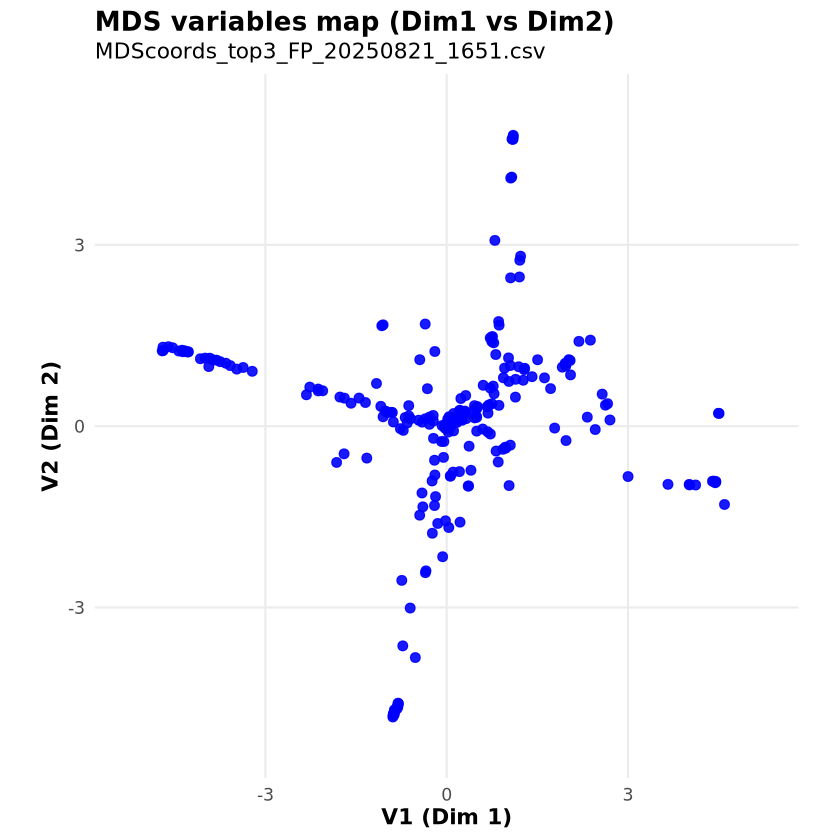

In [18]:
# --- 必要パッケージ ---
if (!require(ggplot2)) install.packages("ggplot2"); library(ggplot2)
if (!require(ggrepel)) install.packages("ggrepel"); library(ggrepel)

# --- 入力（ローカル推奨。URLは/raw/に差し替えが必要） ---
infile <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP/MDScoords_top3_FP_20250821_1651.csv"

# --- 出力先 ---
out_dir <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag <- format(Sys.time(), "%Y%m%d_%H%M")

# ========== 安全読み込み（行名にしない、重複対策） ==========
df_raw <- read.csv(infile, header = TRUE, stringsAsFactors = FALSE, check.names = FALSE)

# write.csv(row.names=TRUE) 由来の先頭列 "X" を変数名として扱う
# そうでなければ、先頭列が文字型なら変数名列とみなす
if ("X" %in% names(df_raw)) {
  var_col <- as.character(df_raw[["X"]])
  df <- df_raw[, setdiff(names(df_raw), "X"), drop = FALSE]
} else if (is.character(df_raw[[1]]) || is.factor(df_raw[[1]])) {
  var_col <- as.character(df_raw[[1]])
  df <- df_raw[, -1, drop = FALSE]
} else {
  # 変数名列が無い場合は行番号を名前にする
  var_col <- paste0("Var", seq_len(nrow(df_raw)))
  df <- df_raw
}

# 変数名の重複を一意化
var_col <- make.unique(var_col, sep = "_dup")

# ========== 軸列の自動検出 ==========
cand_pairs <- list(
  c("V1","V2"),                 # ← ご指定を最優先
  c("MDS1","MDS2"),
  c("Dim1","Dim2"),
  c("Dimension1","Dimension2"),
  c("Axis1","Axis2"),
  c("PC1","PC2")
)

pick_cols <- NULL
for (p in cand_pairs) {
  if (all(p %in% colnames(df))) { pick_cols <- p; break }
}
if (is.null(pick_cols)) {
  # 数値列の先頭2本を使う
  num_cols <- names(df)[vapply(df, is.numeric, logical(1))]
  if (length(num_cols) < 2) stop("第1・第2軸に相当する数値列が見つかりません。")
  pick_cols <- num_cols[1:2]
  message("既知の列名が見つからないため、数値列の先頭2列を使用: ",
          paste(pick_cols, collapse = ", "))
}

xcol <- pick_cols[1]; ycol <- pick_cols[2]

plot_df <- data.frame(
  Var = var_col,
  X   = df[[xcol]],
  Y   = df[[ycol]],
  stringsAsFactors = FALSE
)
plot_df <- na.omit(plot_df)

# スケール調整（正方表示）
rng <- range(c(plot_df$X, plot_df$Y), na.rm = TRUE)
pad <- diff(rng) * 0.05; lims <- c(min(rng) - pad, max(rng) + pad)

# --- プロット作成（ラベルなし、点のみ） ---
p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.4, alpha = 0.9, color = "blue") +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", margin = margin(b = 4))
  ) +
  labs(
    title = "MDS variables map (Dim1 vs Dim2)",
    subtitle = basename(infile),
    x = paste0(xcol, " (Dim 1)"),
    y = paste0(ycol, " (Dim 2)")
  )

# --- コンソールに表示 ---
print(p)

# --- 保存（必要なら） ---
png_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_FP_", ts_tag, ".png"))
pdf_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_FP_", ts_tag, ".pdf"))
ggsave(png_file, p, width = 7.5, height = 6.5, dpi = 300)
ggsave(pdf_file, p, width = 7.5, height = 6.5, device = cairo_pdf)


message("Saved: ", png_file)
message("Saved: ", pdf_file)


Warning message:
"ggrepel: 350 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 351 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 352 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


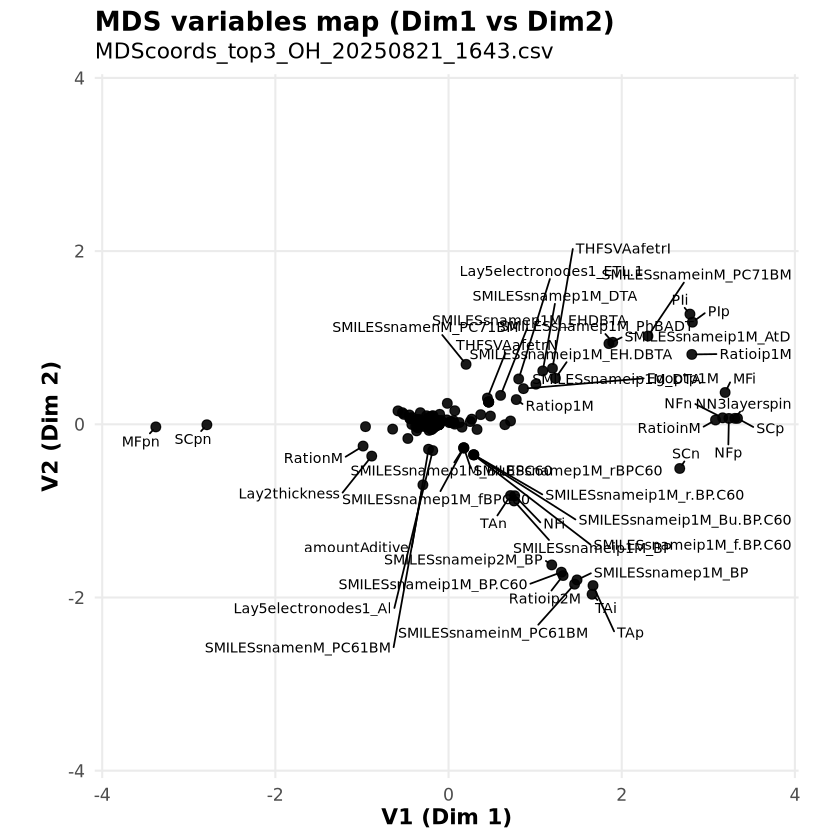

In [13]:
# --- プロット作成 ---
p <- ggplot(plot_df, aes(x = X, y = Y, label = Var)) +
  geom_point(size = 2.4, alpha = 0.9) +
  ggrepel::geom_text_repel(size = 3, max.overlaps = 300,
                           box.padding = 0.3, point.padding = 0.2,
                           min.segment.length = 0) +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  theme(panel.grid.minor = element_blank(),
        axis.title = element_text(face = "bold"),
        plot.title = element_text(face = "bold", margin = margin(b = 4))) +
  labs(title = "MDS variables map (Dim1 vs Dim2)",
       subtitle = basename(infile),
       x = paste0(xcol, " (Dim 1)"),
       y = paste0(ycol, " (Dim 2)"))

# --- コンソールに表示 ---
print(p)

# --- 保存（必要なら） ---
png_file <- file.path(out_dir, paste0("MDS_vars_Dim1v2_OH_", ts_tag, ".png"))
pdf_file <- file.path(out_dir, paste0("MDS_vars_Dim1v2_OH_", ts_tag, ".pdf"))
ggsave(png_file, p, width = 7.5, height = 6.5, dpi = 300)
ggsave(pdf_file, p, width = 7.5, height = 6.5, device = cairo_pdf)


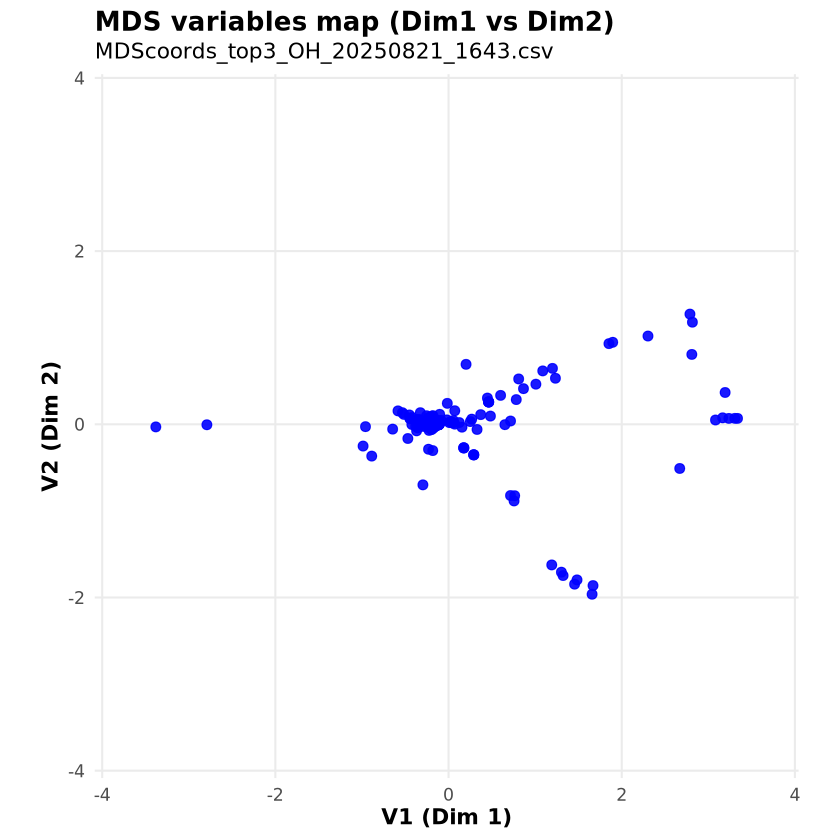

In [14]:
# --- プロット作成（ラベルなし、点のみ） ---
p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.4, alpha = 0.9, color = "blue") +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", margin = margin(b = 4))
  ) +
  labs(
    title = "MDS variables map (Dim1 vs Dim2)",
    subtitle = basename(infile),
    x = paste0(xcol, " (Dim 1)"),
    y = paste0(ycol, " (Dim 2)")
  )

# --- コンソールに表示 ---
print(p)

# --- 保存（必要なら） ---
png_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".png"))
pdf_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".pdf"))
ggsave(png_file, p, width = 7.5, height = 6.5, dpi = 300)
ggsave(pdf_file, p, width = 7.5, height = 6.5, device = cairo_pdf)


In [ ]:
# --- プロット作成（ラベルなし、点のみ） ---
p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.4, alpha = 0.9, color = "blue") +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", margin = margin(b = 4))
  ) +
  labs(
    title = "MDS variables map (Dim1 vs Dim2)",
    subtitle = basename(infile),
    x = paste0(xcol, " (Dim 1)"),
    y = paste0(ycol, " (Dim 2)")
  )

# --- コンソールに表示 ---
print(p)

# --- 保存（必要なら） ---
png_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".png"))
pdf_file <- file.path(out_dir, paste0("MDS_vars_points_Dim1v2_OH_", ts_tag, ".pdf"))
ggsave(png_file, p, width = 7.5, height = 6.5, dpi = 300)
ggsave(pdf_file, p, width = 7.5, height = 6.5, device = cairo_pdf)



Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




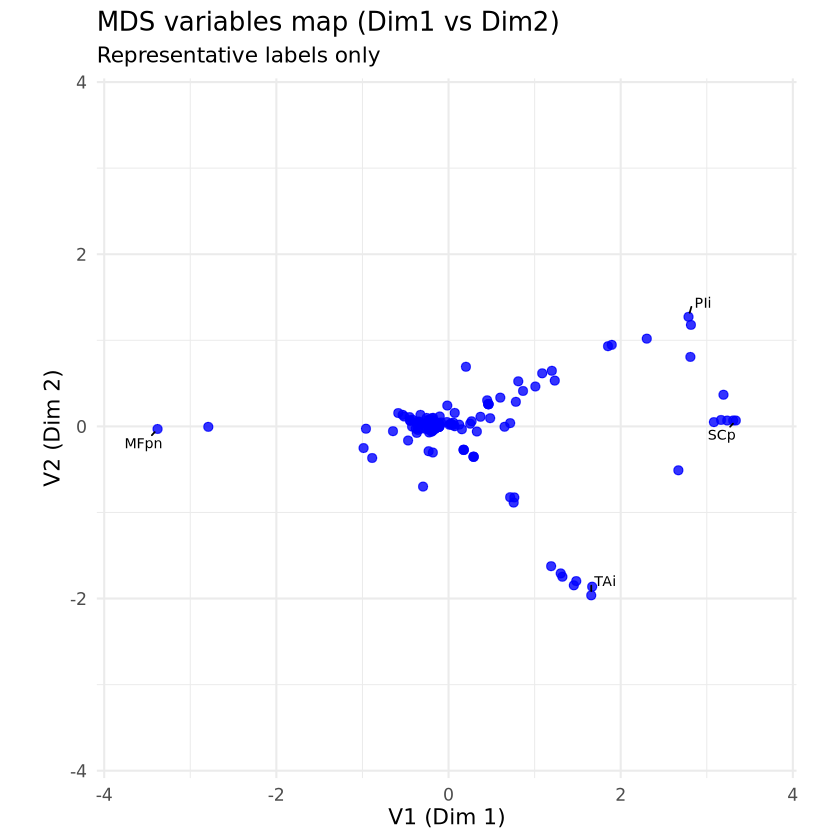

In [15]:
library(dplyr)

# X, Yの最小・最大を取る変数を抽出
extreme_vars <- plot_df %>%
  filter(
    X %in% range(X) |
    Y %in% range(Y)
  )

p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.2, alpha = 0.8, color = "blue") +
  ggrepel::geom_text_repel(
    data = extreme_vars,
    aes(label = Var),
    size = 3,
    box.padding = 0.3,
    point.padding = 0.2,
    min.segment.length = 0,
    max.overlaps = Inf
  ) +
  coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
  theme_minimal(base_size = 13) +
  labs(
    title = "MDS variables map (Dim1 vs Dim2)",
    subtitle = "Representative labels only",
    x = paste0(xcol, " (Dim 1)"),
    y = paste0(ycol, " (Dim 2)")
  )

print(p)


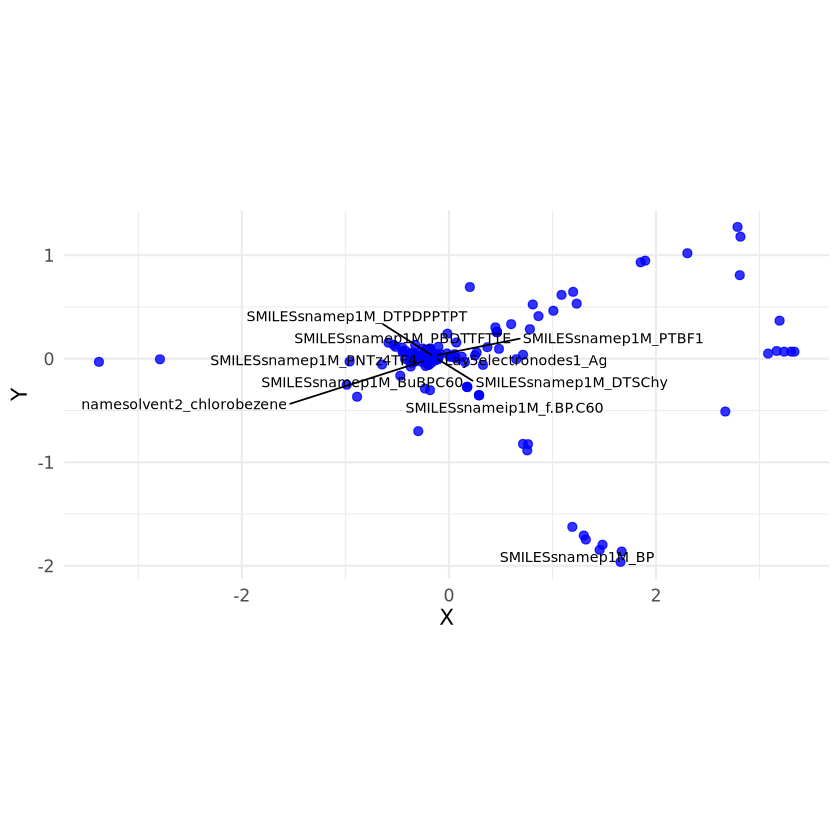

In [16]:
set.seed(42)
rep_vars <- plot_df %>% sample_n(10)   # 例: 10個だけ

p <- ggplot(plot_df, aes(x = X, y = Y)) +
  geom_point(size = 2.2, alpha = 0.8, color = "blue") +
  ggrepel::geom_text_repel(
    data = rep_vars,
    aes(label = Var),
    size = 3, max.overlaps = Inf
  ) +
  coord_equal() +
  theme_minimal(base_size = 13)
print(p)
